# Day 01 — Quantization Basics

**Week 3: Efficient Fine-Tuning & Quantization**

## Why quantization matters

Every number in a neural network (weights, activations) is stored using some number of bits. Fewer bits = less memory, but also less precision. Quantization is the trick of storing weights in a lower-precision format *without* losing much model quality.

| Precision | Bits per weight | Relative size (vs FP32) | Typical use |
|---|---|---|---|
| FP32 | 32 | 1x | Training from scratch, research baselines |
| FP16 / BF16 | 16 | 0.5x | Standard for fine-tuning & inference |
| INT8 | 8 | 0.25x | Inference on memory-constrained GPUs |
| INT4 (NF4) | 4 | 0.125x | QLoRA fine-tuning, running big models on small GPUs |

A 7B parameter model:
- FP32 -> ~28 GB
- FP16 -> ~14 GB
- INT8 -> ~7 GB
- INT4 -> ~3.5 GB

This is *why* QLoRA (Week 3, Day 04) can fine-tune huge models on a single consumer GPU — the base model sits in 4-bit while only small LoRA adapters train in higher precision.

In this notebook we'll load the same small model in all four precisions and compare memory + output quality directly.

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
!pip install -q transformers accelerate bitsandbytes torch
!pip install -q --upgrade --no-cache-dir matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import gc
import json
import time
from dataclasses import dataclass, asdict

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"  # small model so this runs on modest GPUs
PROMPT = "Explain what a neural network is in one sentence."
MAX_NEW_TOKENS = 40

print("CUDA available:", torch.cuda.is_available())

c:\Users\Nemochan\Desktop\ai-engineering-journey\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA available: True


## Helper functions

- `get_gpu_memory_mb()` — reads how much GPU memory is currently allocated
- `clear_memory()` — frees memory between runs so each mode starts from a clean slate
- `load_model(mode)` — loads the model in fp32 / fp16 / int8 / int4

In [4]:
@dataclass
class RunResult:
    mode: str
    load_time_sec: float
    memory_mb: float
    output_text: str
    inference_time_sec: float


def get_gpu_memory_mb() -> float:
    if not torch.cuda.is_available():
        return 0.0
    torch.cuda.synchronize()
    return torch.cuda.memory_allocated() / (1024 ** 2)


def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

In [5]:
def load_model(mode: str):
    """Loads the model in one of: 'fp32', 'fp16', 'int8', 'int4'"""
    common_kwargs = dict(device_map="auto" if torch.cuda.is_available() else None)

    if mode == "fp32":
        model = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME, torch_dtype=torch.float32, **common_kwargs
        )

    elif mode == "fp16":
        model = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME, torch_dtype=torch.float16, **common_kwargs
        )

    elif mode == "int8":
        bnb_config = BitsAndBytesConfig(load_in_8bit=True)
        model = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME, quantization_config=bnb_config, **common_kwargs
        )

    elif mode == "int4":
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_use_double_quant=True,
        )
        model = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME, quantization_config=bnb_config, **common_kwargs
        )

    else:
        raise ValueError(f"Unknown mode: {mode}")

    return model

## Run one mode end-to-end

For each precision we: load the model, measure memory, run the same prompt, and record the output + timing.

In [6]:
def run_mode(mode: str, tokenizer) -> RunResult:
    print(f"\n{'=' * 50}\nRunning mode: {mode.upper()}\n{'=' * 50}")
    clear_memory()

    t0 = time.time()
    model = load_model(mode)
    load_time = time.time() - t0

    memory_mb = get_gpu_memory_mb()

    messages = [{"role": "user", "content": PROMPT}]
    inputs = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, return_tensors="pt", return_dict=True
    ).to(model.device)

    t0 = time.time()
    with torch.no_grad():
        output_ids = model.generate(
            **inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False
        )
    inference_time = time.time() - t0

    input_len = inputs["input_ids"].shape[-1]
    output_text = tokenizer.decode(
        output_ids[0][input_len:], skip_special_tokens=True
    )

    print(f"Load time:      {load_time:.2f}s")
    print(f"GPU memory:     {memory_mb:.1f} MB")
    print(f"Inference time: {inference_time:.2f}s")
    print(f"Output:         {output_text.strip()}")

    result = RunResult(
        mode=mode,
        load_time_sec=round(load_time, 2),
        memory_mb=round(memory_mb, 1),
        output_text=output_text.strip(),
        inference_time_sec=round(inference_time, 2),
    )

    del model
    clear_memory()
    return result

## Run all four modes and compare

Watch the memory numbers drop as we go fp32 -> fp16 -> int8 -> int4, and check whether the output text still makes sense.

In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

modes = ["fp32", "fp16", "int8", "int4"]
results = []

for mode in modes:
    try:
        results.append(run_mode(mode, tokenizer))
    except Exception as e:
        print(f"[{mode}] skipped — {e}")


Running mode: FP32


`torch_dtype` is deprecated! Use `dtype` instead!
W0727 14:10:16.241000 18324 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Load time:      3.17s
GPU memory:     1885.2 MB
Inference time: 2.81s
Output:         A neural network is a complex computational model inspired by the structure and function of the human brain, designed to learn and make predictions based on input data through an iterative process of training and testing.

Running mode: FP16
Load time:      1.97s
GPU memory:     958.1 MB
Inference time: 2.22s
Output:         A neural network is a complex computational model inspired by the structure and function of the human brain, designed to learn and make predictions based on input data through an iterative process of training and testing.

Running mode: INT8
Load time:      5.50s
GPU memory:     611.4 MB
Inference time: 6.32s
Output:         A neural network is a complex computational system inspired by the structure and function of the human brain, designed to learn and make predictions based on input data through an iterative process of training and inference.

Running mode: INT4
Load time:     

In [8]:
print(f"{'Mode':<8}{'Memory (MB)':<15}{'Load (s)':<12}{'Inference (s)':<15}")
print("=" * 55)
for r in results:
    print(f"{r.mode:<8}{r.memory_mb:<15}{r.load_time_sec:<12}{r.inference_time_sec:<15}")

with open("experiment_log.json", "w") as f:
    json.dump([asdict(r) for r in results], f, indent=2)
print("\nSaved full results to experiment_log.json")

Mode    Memory (MB)    Load (s)    Inference (s)  
fp32    1885.2         3.17        2.81           
fp16    958.1          1.97        2.22           
int8    611.4          5.5         6.32           
int4    445.4          2.11        1.51           

Saved full results to experiment_log.json


## Visualize the comparison

A printed table is useful, but a chart makes the memory drop impossible to miss. This builds a 3-panel bar chart — memory, load time, inference time — directly from the `results` we just collected.

Saved chart to quantization_comparison.png


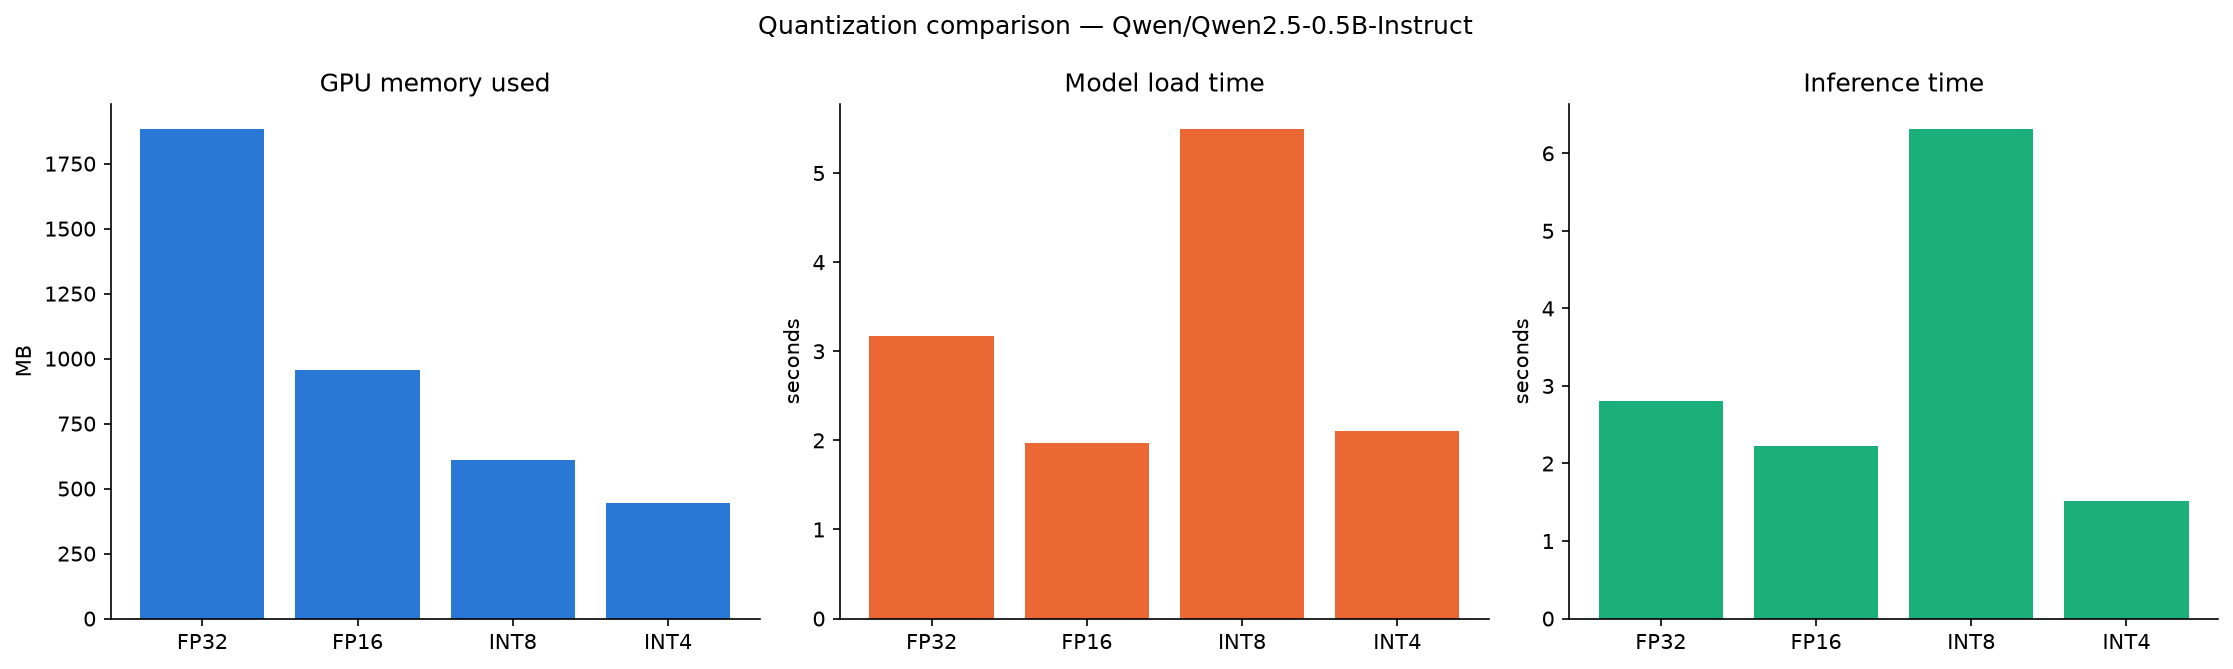

In [9]:
try:
    import matplotlib.pyplot as plt

    modes_upper = [r.mode.upper() for r in results]
    memory = [r.memory_mb for r in results]
    load_times = [r.load_time_sec for r in results]
    inference_times = [r.inference_time_sec for r in results]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    axes[0].bar(modes_upper, memory, color="#2a78d6")
    axes[0].set_title("GPU memory used")
    axes[0].set_ylabel("MB")

    axes[1].bar(modes_upper, load_times, color="#eb6834")
    axes[1].set_title("Model load time")
    axes[1].set_ylabel("seconds")

    axes[2].bar(modes_upper, inference_times, color="#1baf7a")
    axes[2].set_title("Inference time")
    axes[2].set_ylabel("seconds")

    for ax in axes:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle(f"Quantization comparison — {MODEL_NAME}", fontsize=12)
    plt.tight_layout()
    plt.savefig("quantization_comparison.png", dpi=150, bbox_inches="tight")
    plt.close(fig)  # avoid relying on plt.show()'s interactive renderer

    print("Saved chart to quantization_comparison.png")

    # Display as a static image instead of plt.show() — more resilient
    # against Colab's "Could not load the JavaScript files" rendering
    # issue, and against local Jupyter backend problems too.
    from IPython.display import Image, display
    display(Image("quantization_comparison.png"))

except Exception as e:
    # Matplotlib can fail for environment-specific reasons (corrupted
    # install locally, broken frontend rendering on Colab, missing
    # backend, etc.) that have nothing to do with the experiment data
    # itself. Rather than crashing the notebook, fall back to printing
    # the same numbers as a plain table.
    print(f"Chart skipped — matplotlib failed to plot ({type(e).__name__}: {e})")
    print("If this happens locally, try: pip uninstall matplotlib -y && pip install --no-cache-dir matplotlib")
    print("Raw results, in table form:\n")
    print(f"{'Mode':<8}{'Memory (MB)':<15}{'Load (s)':<12}{'Inference (s)':<15}")
    print("=" * 55)
    for r in results:
        print(f"{r.mode:<8}{r.memory_mb:<15}{r.load_time_sec:<12}{r.inference_time_sec:<15}")

## What to look for

1. **Memory**: fp32 should use the most, int4 the least — often 6-8x smaller.
2. **Load time**: quantized models sometimes take *longer* to load (the quantization step itself costs time), even though they run leaner afterward.
3. **Output quality**: for a 0.5B model on a simple prompt, fp16/int8/int4 outputs should all still be coherent — the quality loss becomes more noticeable on harder prompts or lower-quality quantization schemes.

## Key takeaways

- Quantization trades a small amount of precision for large memory savings.
- FP16 is nearly free — always prefer it over FP32 unless you specifically need full precision.
- INT8/INT4 quantization (via `bitsandbytes`) is what makes it possible to fine-tune multi-billion parameter models on a single consumer GPU — this is the foundation for **QLoRA**, coming in Day 04.

Next up: **Day 02 — LoRA**, where instead of shrinking the whole model, we freeze it and train small adapter matrices on top.